In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
epl = pd.read_csv("epl.csv")
psg = pd.read_csv("league 1.csv")
ucl = pd.read_csv("ucl match stats/champions_league_matches.csv")

# Filter Arsenal EPL matches
arsenal_epl = epl[(epl['HomeTeam'] == 'Arsenal') | (epl['AwayTeam'] == 'Arsenal')]
arsenal_home = arsenal_epl[arsenal_epl['HomeTeam'] == 'Arsenal']
arsenal_away = arsenal_epl[arsenal_epl['AwayTeam'] == 'Arsenal']

# Filter PSG Ligue 1 matches
psg_matches = psg[(psg['HomeTeam'] == 'Paris SG') | (psg['AwayTeam'] == 'Paris SG')]
psg_home = psg_matches[psg_matches['HomeTeam'] == 'Paris SG']
psg_away = psg_matches[psg_matches['AwayTeam'] == 'Paris SG']

# Filter UCL matches
arsenal_ucl = ucl[(ucl['home_team'] == 'Arsenal') | (ucl['away_team'] == 'Arsenal')]
psg_ucl = ucl[(ucl['home_team'] == 'Paris Saint-Germain') | (ucl['away_team'] == 'Paris Saint-Germain')]

print("✅ All datasets loaded!")
print(f"Arsenal EPL matches: {arsenal_epl.shape[0]}")
print(f"PSG Ligue 1 matches: {psg_matches.shape[0]}")
print(f"Arsenal UCL matches: {arsenal_ucl.shape[0]}")
print(f"PSG UCL matches: {psg_ucl.shape[0]}")

✅ All datasets loaded!
Arsenal EPL matches: 37
PSG Ligue 1 matches: 34
Arsenal UCL matches: 8
PSG UCL matches: 8


In [2]:
# Load player data
players = pd.read_csv("player stats/players_data-2025_2026.csv")

# Filter Arsenal and PSG players
arsenal_players = players[players['Squad'] == 'Arsenal'][['Player', 'Pos', 'MP', 'Gls', 'Ast', 'G+A', 'Min']].dropna(subset=['Gls'])
psg_players = players[players['Squad'] == 'Paris Saint-Germain'][['Player', 'Pos', 'MP', 'Gls', 'Ast', 'G+A', 'Min']].dropna(subset=['Gls'])

# Sort by goals + assists
arsenal_players = arsenal_players.sort_values('G+A', ascending=False).head(10)
psg_players = psg_players.sort_values('G+A', ascending=False).head(10)

print("=== ARSENAL TOP 10 PLAYERS ===")
print(arsenal_players.to_string(index=False))
print("\n=== PSG TOP 10 PLAYERS ===")
print(psg_players.to_string(index=False))

=== ARSENAL TOP 10 PLAYERS ===
           Player   Pos  MP  Gls  Ast  G+A  Min
  Viktor Gyökeres    FW  33   14    1   15 2108
 Leandro Trossard FW,MF  29    5    6   11 1821
      Bukayo Saka FW,MF  29    7    4   11 2053
     Eberechi Eze MF,FW  29    7    2    9 1658
      Declan Rice    MF  34    4    5    9 2914
   Jurriën Timber    DF  30    3    5    8 2454
     Mikel Merino MF,FW  21    4    3    7 1007
Gabriel Magalhães    DF  29    3    4    7 2526
 Martín Zubimendi    MF  35    5    1    6 2862
  Martin Ødegaard    MF  22    1    5    6 1256

=== PSG TOP 10 PLAYERS ===
               Player   Pos  MP  Gls  Ast  G+A  Min
      Ousmane Dembélé    FW  19   10    6   16  932
Khvicha Kvaratskhelia    FW  25    7    4   11 1321
      Bradley Barcola    FW  26   10    1   11 1573
          Désiré Doué FW,MF  21    6    3    9 1220
          Nuno Mendes    DF  20    4    5    9 1256
         Senny Mayulu MF,FW  23    4    4    8 1459
              Vitinha    MF  27    1    7    8 20

In [3]:
# Defensive player stats
defensive_cols = ['Player', 'Pos', 'Squad', 'MP', 'Min', 'CrdY', 'CrdR']

# We need tackles, interceptions etc - check what columns exist
print(players.columns.tolist())

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_s

In [4]:
# Arsenal defensive players (DF and MF)
arsenal_def = players[players['Squad'] == 'Arsenal'][
    ['Player', 'Pos', 'MP', 'Min', 'TklW', 'Int', 'CrdY', 'Fls']
].dropna(subset=['TklW']).sort_values('TklW', ascending=False).head(8)

# PSG defensive players
psg_def = players[players['Squad'] == 'Paris Saint-Germain'][
    ['Player', 'Pos', 'MP', 'Min', 'TklW', 'Int', 'CrdY', 'Fls']
].dropna(subset=['TklW']).sort_values('TklW', ascending=False).head(8)

print("=== ARSENAL DEFENSIVE STATS ===")
print(arsenal_def.to_string(index=False))
print("\n=== PSG DEFENSIVE STATS ===")
print(psg_def.to_string(index=False))

=== ARSENAL DEFENSIVE STATS ===
            Player Pos  MP  Min  TklW  Int  CrdY  Fls
  Martín Zubimendi  MF  35 2862    39   39     4   31
    Jurriën Timber  DF  30 2454    35   24     5   38
       Declan Rice  MF  34 2914    31   31     3   26
    Piero Hincapié  DF  23 1683    25   24     2   18
    William Saliba  DF  29 2434    21   15     1   21
 Gabriel Magalhães  DF  29 2526    20   21     4   18
Cristhian Mosquera  DF  17  769    19    8     3   13
Riccardo Calafiori  DF  23 1538    19   13     5   25

=== PSG DEFENSIVE STATS ===
            Player   Pos  MP  Min  TklW  Int  CrdY  Fls
Warren Zaïre-Emery DF,MF  31 2390    29   11     3   35
     Willian Pacho    DF  23 1914    26   26     0    6
      Senny Mayulu MF,FW  23 1459    25    8     2   22
       Nuno Mendes    DF  20 1256    20   14     1   12
       Désiré Doué FW,MF  21 1220    19    8     0   23
           Vitinha    MF  27 2007    19   24     2   13
    Illia Zabarnyi    DF  25 2117    17   16     5   17
   Br

⚙️  Extracting 26 Metrics...
✅ All 26 metrics extracted successfully!

📊 Running Weighted Score System...

Feature                        Arsenal       PSG    Wt  Edge
-----------------------------------------------------------------
Win Rate                         0.676     0.706   2.0  🔵 PSG
Avg Goals Scored                 1.865     2.176   1.5  🔵 PSG
Avg Goals Conceded (inv)         0.853     0.703   2.0  🔴 ARS
Shots on Target/Game             4.833     6.676   1.5  🔵 PSG
Goals Per Shot                   0.129     0.123   1.5  🔴 ARS
Defensive Strength               7.324     7.676   2.0  🔵 PSG
Clean Sheet Rate                 0.514     0.529   2.0  🔵 PSG
UCL Goals/Game                   2.875     2.625   3.0  🔴 ARS
UCL Conceded/Game (inv)          1.375     0.500   3.0  🔴 ARS
UCL Win Rate                     1.000     0.500   3.0  🔴 ARS
Corners/Game                     5.725     6.353   1.0  🔵 PSG
Yellow Cards (inv)               1.059     1.364   1.0  🔵 PSG
Top 3 Goals           

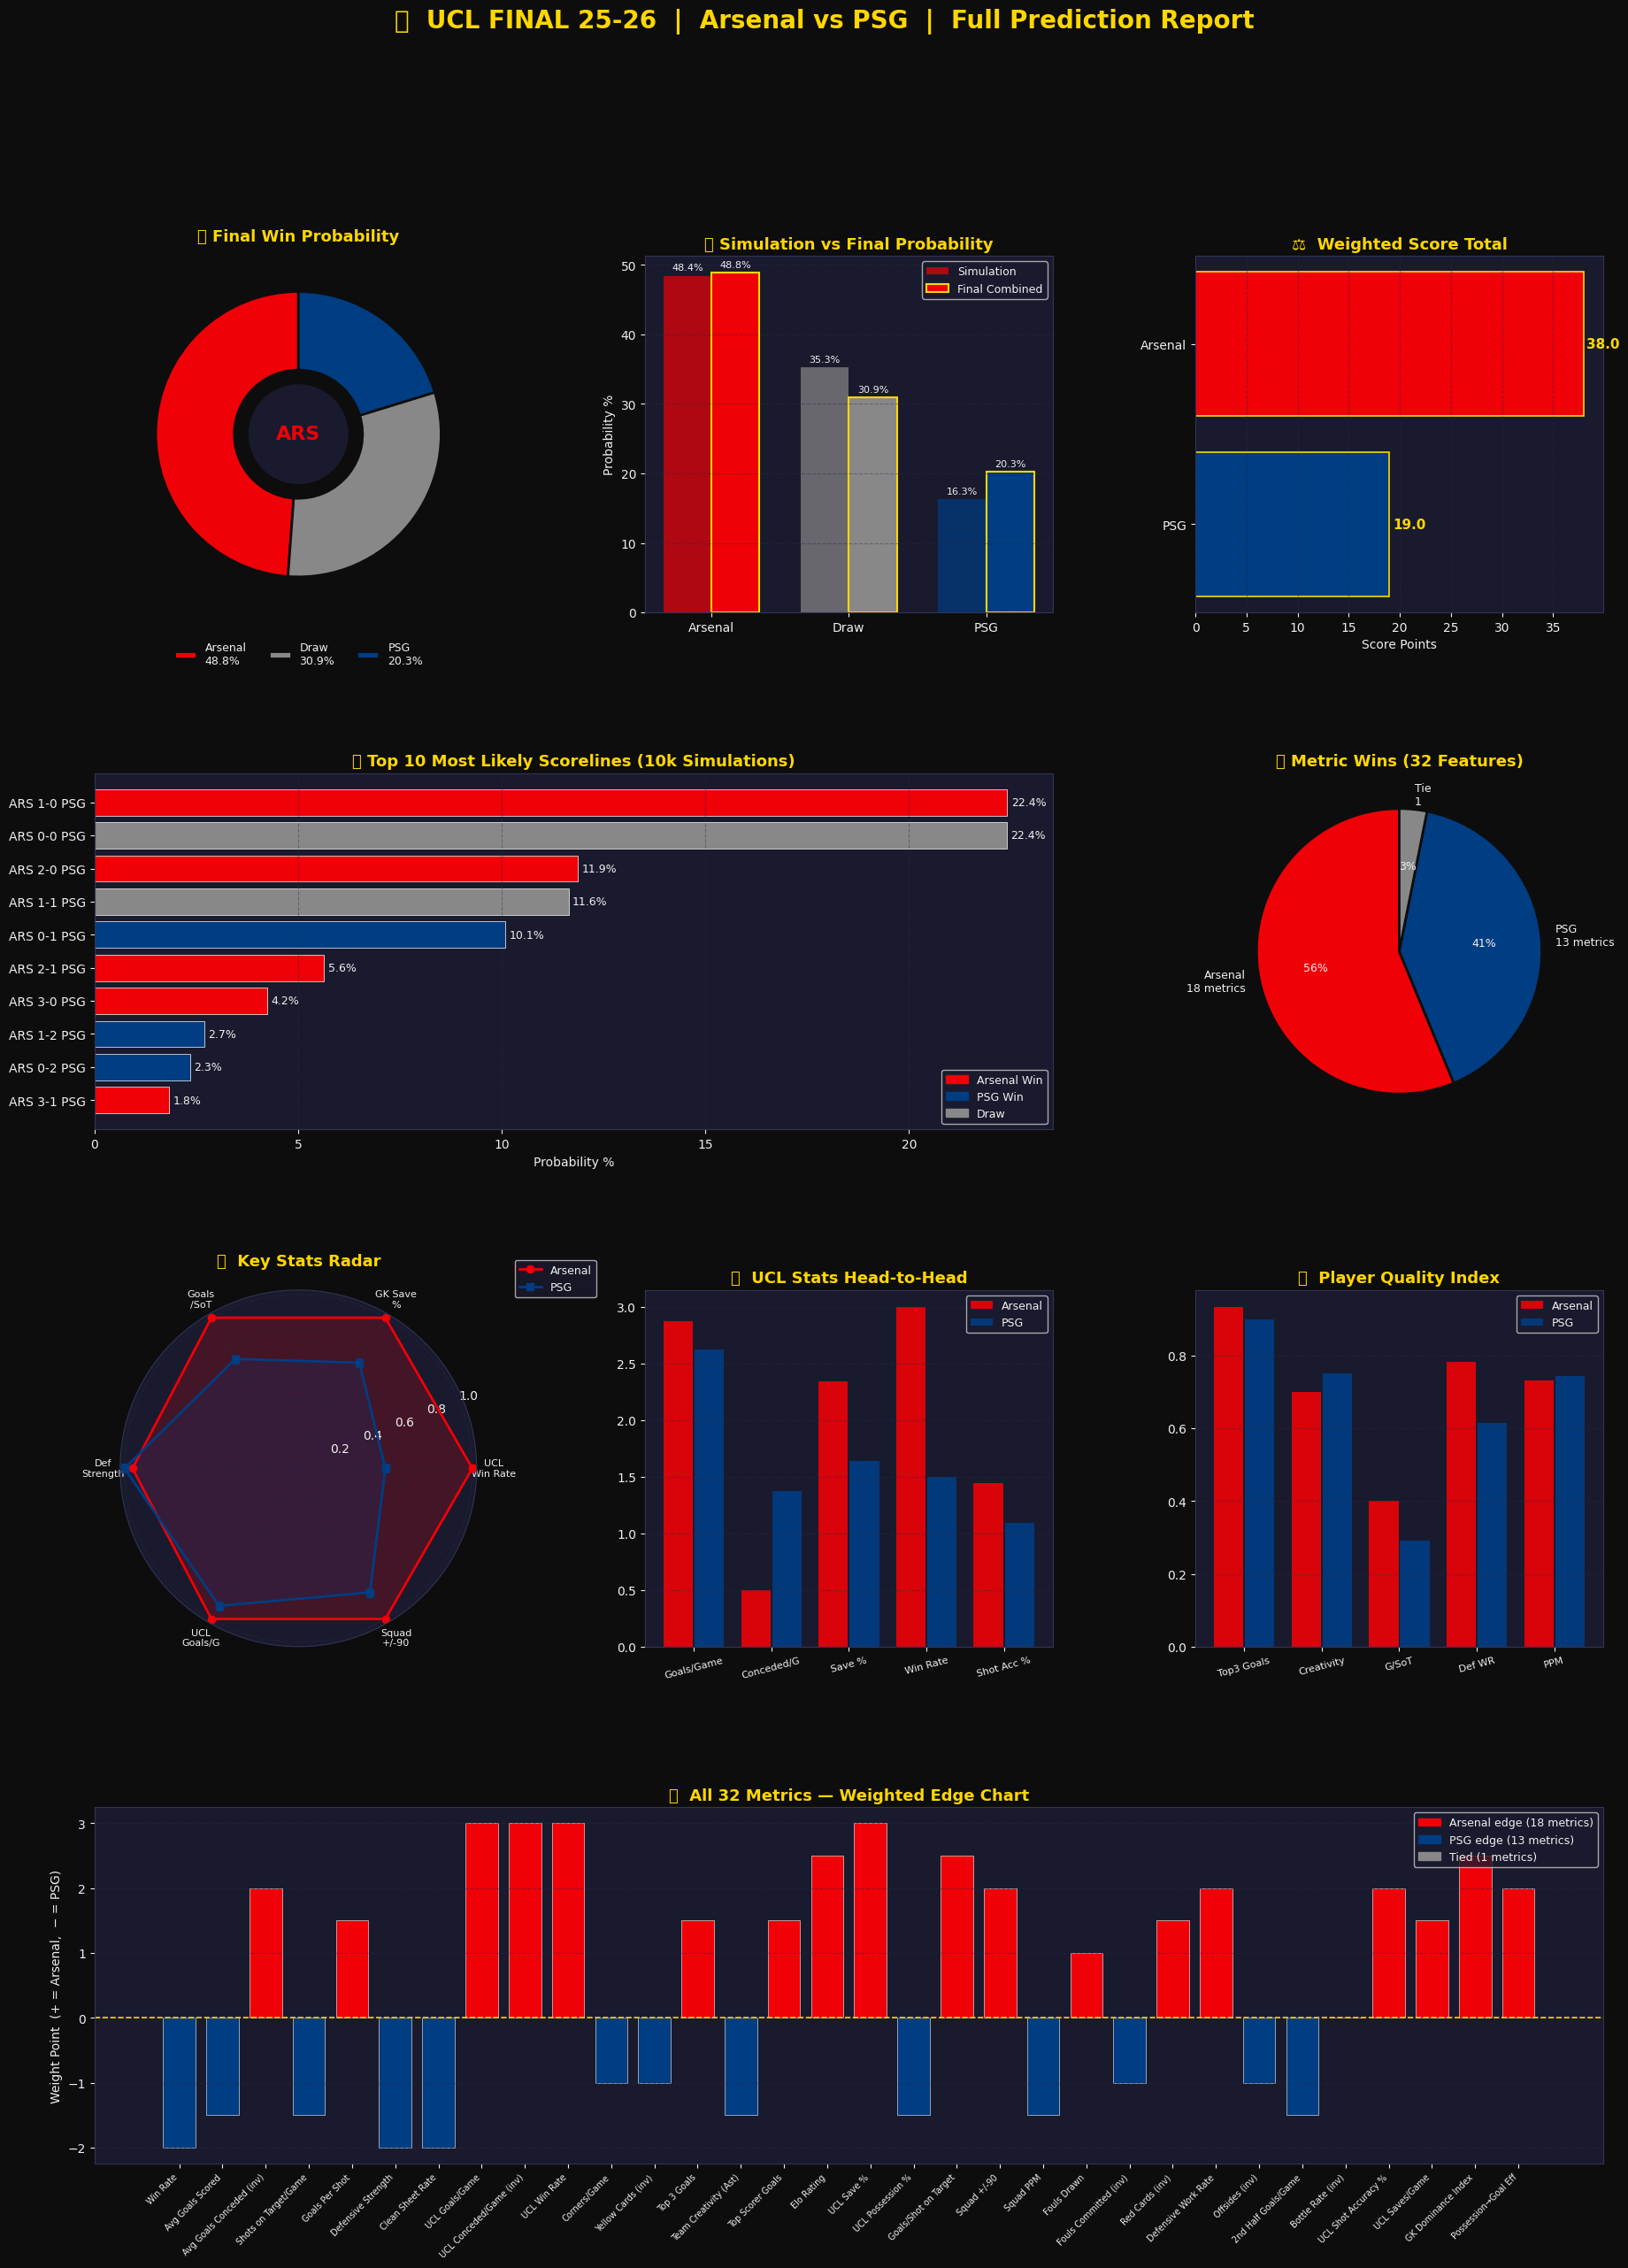


✅ Saved → ../Output/ucl_final_full_prediction.png


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║        UCL FINAL 25-26 — FULL PREDICTION MODEL              ║
# ║        Arsenal vs PSG — Combined 26-Metric System           ║
# ╚══════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# CELL 1 — LOAD DATA
# ─────────────────────────────────────────────────────────────

epl     = pd.read_csv('../Data/epl.csv')
ligue1  = pd.read_csv('../Data/league 1.csv')
ucl     = pd.read_csv('../Data/ucl match stats/champions_league_matches.csv')
players = pd.read_csv('../Data/player stats/players_data-2025_2026.csv')

ucl[['home_goals', 'away_goals']] = ucl['score'].str.split('–', expand=True).astype(float)

# ── Subset by team
arsenal_home    = epl[epl['HomeTeam'] == 'Arsenal']
arsenal_away    = epl[epl['AwayTeam'] == 'Arsenal']
arsenal_epl     = epl[(epl['HomeTeam'] == 'Arsenal') | (epl['AwayTeam'] == 'Arsenal')]

psg_home        = ligue1[ligue1['HomeTeam'] == 'Paris SG']
psg_away        = ligue1[ligue1['AwayTeam'] == 'Paris SG']
psg_matches     = ligue1[(ligue1['HomeTeam'] == 'Paris SG') | (ligue1['AwayTeam'] == 'Paris SG')]

arsenal_ucl     = ucl[(ucl['home_team'] == 'Arsenal') | (ucl['away_team'] == 'Arsenal')]
psg_ucl         = ucl[(ucl['home_team'] == 'Paris Saint-Germain') | (ucl['away_team'] == 'Paris Saint-Germain')]

arsenal_players = players[players['Squad'] == 'Arsenal'].sort_values('Gls', ascending=False)
psg_players     = players[players['Squad'] == 'Paris Saint-Germain'].sort_values('Gls', ascending=False)

arsenal_def     = arsenal_players[arsenal_players['Pos'].str.contains('DF', na=False)]
psg_def         = psg_players[psg_players['Pos'].str.contains('DF', na=False)]

# ── Base aggregates
arsenal_goals_scored   = arsenal_home['FTHG'].sum() + arsenal_away['FTAG'].sum()
arsenal_goals_conceded = arsenal_home['FTAG'].sum() + arsenal_away['FTHG'].sum()
psg_goals_scored       = psg_home['FTHG'].sum()     + psg_away['FTAG'].sum()
psg_goals_conceded     = psg_home['FTAG'].sum()     + psg_away['FTHG'].sum()

arsenal_wins = len(arsenal_home[arsenal_home['FTR']=='H']) + len(arsenal_away[arsenal_away['FTR']=='A'])
psg_wins     = len(psg_home[psg_home['FTR']=='H'])         + len(psg_away[psg_away['FTR']=='A'])

arsenal_cs = len(arsenal_home[arsenal_home['FTAG']==0]) + len(arsenal_away[arsenal_away['FTHG']==0])
psg_cs     = len(psg_home[psg_home['FTAG']==0])         + len(psg_away[psg_away['FTHG']==0])

# UCL goals
arsenal_ucl_goals_for = arsenal_ucl_goals_against = 0
for _, r in arsenal_ucl.iterrows():
    if r['home_team'] == 'Arsenal':
        arsenal_ucl_goals_for     += r['home_goals']
        arsenal_ucl_goals_against += r['away_goals']
    else:
        arsenal_ucl_goals_for     += r['away_goals']
        arsenal_ucl_goals_against += r['home_goals']

psg_ucl_goals_for = psg_ucl_goals_against = 0
for _, r in psg_ucl.iterrows():
    if r['home_team'] == 'Paris Saint-Germain':
        psg_ucl_goals_for     += r['home_goals']
        psg_ucl_goals_against += r['away_goals']
    else:
        psg_ucl_goals_for     += r['away_goals']
        psg_ucl_goals_against += r['home_goals']

arsenal_ucl_wins = len(arsenal_ucl[arsenal_ucl['winner'] == 'Arsenal'])
psg_ucl_wins     = len(psg_ucl[psg_ucl['winner'] == 'Paris Saint-Germain'])


# ─────────────────────────────────────────────────────────────
# CELL 2 — EXTRACT ALL 26 METRICS
# ─────────────────────────────────────────────────────────────

print("⚙️  Extracting 26 Metrics...")
print("=" * 60)

# ── ORIGINAL 10 METRIC GROUPS ──────────────────────────────

# 1. Goals per game
a_avg_scored   = arsenal_goals_scored   / len(arsenal_epl)
p_avg_scored   = psg_goals_scored       / len(psg_matches)
a_avg_conceded = arsenal_goals_conceded / len(arsenal_epl)
p_avg_conceded = psg_goals_conceded     / len(psg_matches)

# 2. Shots & efficiency
a_sot_pg   = (arsenal_home['HST'].mean() + arsenal_away['AST'].mean()) / 2
p_sot_pg   = (psg_home['HST'].mean()     + psg_away['AST'].mean())     / 2
a_shots_pg = (arsenal_home['HS'].mean()  + arsenal_away['AS'].mean())  / 2
p_shots_pg = (psg_home['HS'].mean()      + psg_away['AS'].mean())      / 2
a_gps      = a_avg_scored / (a_shots_pg + 1e-6)
p_gps      = p_avg_scored / (p_shots_pg + 1e-6)

# 3. Defensive strength (TklW + Int from player dataset)
a_def_str  = (arsenal_def['TklW'].sum() + arsenal_def['Int'].sum()) / len(arsenal_epl)
p_def_str  = (psg_def['TklW'].sum()     + psg_def['Int'].sum())     / len(psg_matches)

# 4. Discipline — yellow cards
a_cards = (arsenal_home['HY'].mean() + arsenal_away['AY'].mean()) / 2
p_cards = (psg_home['HY'].mean()     + psg_away['AY'].mean())     / 2

# 5. Corners per game
a_corners = (arsenal_home['HC'].mean() + arsenal_away['AC'].mean()) / 2
p_corners = (psg_home['HC'].mean()     + psg_away['AC'].mean())     / 2

# 6. Clean sheet rate
a_cs_rate = arsenal_cs / len(arsenal_epl)
p_cs_rate = psg_cs     / len(psg_matches)

# 7. UCL goals per game
a_ucl_scored   = arsenal_ucl_goals_for     / len(arsenal_ucl)
p_ucl_scored   = psg_ucl_goals_for         / len(psg_ucl)
a_ucl_conceded = arsenal_ucl_goals_against / len(arsenal_ucl)
p_ucl_conceded = psg_ucl_goals_against     / len(psg_ucl)

# 8. UCL win rate
a_ucl_win_rate = arsenal_ucl_wins / len(arsenal_ucl)
p_ucl_win_rate = psg_ucl_wins     / len(psg_ucl)

# 9. Player quality
a_top3_goals   = float(arsenal_players.head(3)['Gls'].sum())
p_top3_goals   = float(psg_players.head(3)['Gls'].sum())
a_creativity   = float(arsenal_players.head(5)['Ast'].sum())
p_creativity   = float(psg_players.head(5)['Ast'].sum())
a_top_scorer   = float(arsenal_players.iloc[0]['Gls'])
p_top_scorer   = float(psg_players.iloc[0]['Gls'])

# 10. Elo & win rate
a_elo      = 1850
p_elo      = 1780
a_win_rate = arsenal_wins / len(arsenal_epl)
p_win_rate = psg_wins     / len(psg_matches)

# ── NEW 16 METRICS ─────────────────────────────────────────

# 11. UCL Goalkeeper Save %
def get_save_pct(team_ucl, name):
    h = team_ucl[team_ucl['home_team'] == name]['home_saves_pct']
    a = team_ucl[team_ucl['away_team'] == name]['away_saves_pct']
    return pd.concat([h, a]).mean()

a_save_pct = get_save_pct(arsenal_ucl, 'Arsenal')
p_save_pct = get_save_pct(psg_ucl, 'Paris Saint-Germain')

# 12. UCL Possession %
def get_poss(team_ucl, name):
    h = team_ucl[team_ucl['home_team'] == name]['home_possession'].str.replace('%','').astype(float)
    a = team_ucl[team_ucl['away_team'] == name]['away_possession'].str.replace('%','').astype(float)
    return pd.concat([h, a]).mean()

a_poss = get_poss(arsenal_ucl, 'Arsenal')
p_poss = get_poss(psg_ucl, 'Paris Saint-Germain')

# 13. Goals per Shot on Target (finishing quality)
a_gsot = arsenal_players[arsenal_players['G/SoT'].notna()]['G/SoT'].mean()
p_gsot = psg_players[psg_players['G/SoT'].notna()]['G/SoT'].mean()

# 14. Squad +/-90 (goal diff per 90 min when on field)
a_pm90 = arsenal_players['+/-90'].mean()
p_pm90 = psg_players['+/-90'].mean()

# 15. Squad PPM (Points per Match — form indicator)
a_ppm = arsenal_players['PPM'].mean()
p_ppm = psg_players['PPM'].mean()

# 16. Fouls Drawn (winning set pieces)
a_fld = float(arsenal_players['Fld'].sum())
p_fld = float(psg_players['Fld'].sum())

# 17. Fouls Committed per game
a_fouls = (arsenal_home['HF'].mean() + arsenal_away['AF'].mean()) / 2
p_fouls = (psg_home['HF'].mean()     + psg_away['AF'].mean())     / 2

# 18. Red Cards per game
a_reds = (arsenal_home['HR'].mean() + arsenal_away['AR'].mean()) / 2
p_reds = (psg_home['HR'].mean()     + psg_away['AR'].mean())     / 2

# 19. Defensive Work Rate per player (TklW + Int average)
a_def_wr = arsenal_players['TklW'].mean() + arsenal_players['Int'].mean()
p_def_wr = psg_players['TklW'].mean()     + psg_players['Int'].mean()

# 20. Offsides (lower = better discipline in attack)
a_off = float(arsenal_players['Off'].sum())
p_off = float(psg_players['Off'].sum())

# 21. Second Half Goals per game (late game strength)
a_2h = ((arsenal_home['FTHG'] - arsenal_home['HTHG']).mean() +
        (arsenal_away['FTAG'] - arsenal_away['HTAG']).mean()) / 2
p_2h = ((psg_home['FTHG'] - psg_home['HTHG']).mean() +
        (psg_away['FTAG'] - psg_away['HTAG']).mean()) / 2

# 22. Bottle Rate (led at HT but didn't win — mental fragility)
a_led_ht = arsenal_home[arsenal_home['HTHG'] > arsenal_home['HTAG']]
a_bottle  = len(a_led_ht[a_led_ht['FTR'] != 'H']) / (len(a_led_ht) + 1e-6)
p_led_ht  = psg_home[psg_home['HTHG'] > psg_home['HTAG']]
p_bottle  = len(p_led_ht[p_led_ht['FTR'] != 'H']) / (len(p_led_ht) + 1e-6)

# 23. UCL Shot Accuracy %
def get_shot_acc(team_ucl, name):
    h = team_ucl[team_ucl['home_team'] == name]['home_shots_on_target_pct']
    a = team_ucl[team_ucl['away_team'] == name]['away_shots_on_target_pct']
    return pd.concat([h, a]).mean()

a_shot_acc = get_shot_acc(arsenal_ucl, 'Arsenal')
p_shot_acc = get_shot_acc(psg_ucl, 'Paris Saint-Germain')

# 24. UCL Saves per game
def get_saves_pg(team_ucl, name):
    h = team_ucl[team_ucl['home_team'] == name]['home_saves'].str.split(' of ').str[0].astype(float)
    a = team_ucl[team_ucl['away_team'] == name]['away_saves'].str.split(' of ').str[0].astype(float)
    return pd.concat([h, a]).mean()

a_saves_pg = get_saves_pg(arsenal_ucl, 'Arsenal')
p_saves_pg = get_saves_pg(psg_ucl, 'Paris Saint-Germain')

# 25. GK Dominance Index = Save% × Saves per game
a_gk_dom = a_save_pct * a_saves_pg
p_gk_dom = p_save_pct * p_saves_pg

# 26. Possession-to-Goal Efficiency (UCL goals per % possession)
a_pos_eff = a_ucl_scored / (a_poss + 1e-6)
p_pos_eff = p_ucl_scored / (p_poss + 1e-6)

print("✅ All 26 metrics extracted successfully!\n")


# ─────────────────────────────────────────────────────────────
# CELL 3 — WEIGHTED SCORE SYSTEM (26 FEATURES)
# ─────────────────────────────────────────────────────────────

print("📊 Running Weighted Score System...")
print("=" * 70)

features = {
    # ── ORIGINAL METRICS
    'Win Rate':                (a_win_rate,    p_win_rate,     2.0),
    'Avg Goals Scored':        (a_avg_scored,  p_avg_scored,   1.5),
    'Avg Goals Conceded (inv)':(p_avg_conceded,a_avg_conceded, 2.0),
    'Shots on Target/Game':    (a_sot_pg,      p_sot_pg,       1.5),
    'Goals Per Shot':          (a_gps,         p_gps,          1.5),
    'Defensive Strength':      (a_def_str,     p_def_str,      2.0),
    'Clean Sheet Rate':        (a_cs_rate,     p_cs_rate,      2.0),
    'UCL Goals/Game':          (a_ucl_scored,  p_ucl_scored,   3.0),
    'UCL Conceded/Game (inv)': (p_ucl_conceded,a_ucl_conceded, 3.0),
    'UCL Win Rate':            (a_ucl_win_rate,p_ucl_win_rate, 3.0),
    'Corners/Game':            (a_corners,     p_corners,      1.0),
    'Yellow Cards (inv)':      (p_cards,       a_cards,        1.0),
    'Top 3 Goals':             (a_top3_goals,  p_top3_goals,   1.5),
    'Team Creativity (Ast)':   (a_creativity,  p_creativity,   1.5),
    'Top Scorer Goals':        (a_top_scorer,  p_top_scorer,   1.5),
    'Elo Rating':              (a_elo,         p_elo,          2.5),
    # ── NEW METRICS
    'UCL Save %':              (a_save_pct,    p_save_pct,     3.0),
    'UCL Possession %':        (a_poss,        p_poss,         1.5),
    'Goals/Shot on Target':    (a_gsot,        p_gsot,         2.5),
    'Squad +/-90':             (a_pm90,        p_pm90,         2.0),
    'Squad PPM':               (a_ppm,         p_ppm,          1.5),
    'Fouls Drawn':             (a_fld,         p_fld,          1.0),
    'Fouls Committed (inv)':   (p_fouls,       a_fouls,        1.0),
    'Red Cards (inv)':         (p_reds,        a_reds,         1.5),
    'Defensive Work Rate':     (a_def_wr,      p_def_wr,       2.0),
    'Offsides (inv)':          (p_off,         a_off,          1.0),
    '2nd Half Goals/Game':     (a_2h,          p_2h,           1.5),
    'Bottle Rate (inv)':       (p_bottle,      a_bottle,       2.0),
    'UCL Shot Accuracy %':     (a_shot_acc,    p_shot_acc,     2.0),
    'UCL Saves/Game':          (a_saves_pg,    p_saves_pg,     1.5),
    'GK Dominance Index':      (a_gk_dom,      p_gk_dom,       2.5),
    'Possession→Goal Eff':     (a_pos_eff,     p_pos_eff,      2.0),
}

arsenal_weighted = 0
psg_weighted     = 0
total_weight     = 0
feature_results  = {}

print(f"\n{'Feature':<28} {'Arsenal':>9} {'PSG':>9} {'Wt':>5}  Edge")
print("-" * 65)

for feature, (a_val, p_val, weight) in features.items():
    if a_val > p_val:
        arsenal_weighted += weight
        edge = '🔴 ARS'
        winner = 'Arsenal'
    elif p_val > a_val:
        psg_weighted += weight
        edge = '🔵 PSG'
        winner = 'PSG'
    else:
        edge = '⚪ TIE'
        winner = 'Tie'
    total_weight += weight
    feature_results[feature] = {
        'arsenal': a_val, 'psg': p_val,
        'weight': weight, 'winner': winner
    }
    print(f"{feature:<28} {a_val:>9.3f} {p_val:>9.3f} {weight:>5.1f}  {edge}")

print("-" * 65)
print(f"{'WEIGHTED SCORE':<28} {arsenal_weighted:>9.1f} {psg_weighted:>9.1f}")


# ─────────────────────────────────────────────────────────────
# CELL 4 — POISSON + DIXON-COLES 10,000 SIMULATION
# ─────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────
# CELL 4 — FIXED POISSON + DIXON-COLES 10,000 SIMULATION
# ─────────────────────────────────────────────────────────────

print(f"\n{'=' * 60}")
print("⚽  Poisson + Dixon-Coles Simulation (10,000 matches)")
print(f"{'=' * 60}")

# ── Ensure home_goals/away_goals exist
if 'home_goals' not in ucl.columns:
    ucl[['home_goals', 'away_goals']] = ucl['score'].str.split('–', expand=True).astype(float)

# ── Fix variable name
ligue1 = psg  # your Ligue 1 data is loaded as 'psg'

# ── League averages (baseline)
epl_avg_gpg = (epl['FTHG'].sum()       + epl['FTAG'].sum())       / len(epl)
l1_avg_gpg  = (ligue1['FTHG'].sum()    + ligue1['FTAG'].sum())    / len(ligue1)
ucl_avg_gpg = (ucl['home_goals'].sum() + ucl['away_goals'].sum()) / len(ucl)

print(f"\n  League Averages (goals/game):")
print(f"  EPL    : {epl_avg_gpg:.3f}")
print(f"  Ligue 1: {l1_avg_gpg:.3f}")
print(f"  UCL    : {ucl_avg_gpg:.3f}")

# ── League attack/defense ratings (normalized vs league avg)
a_epl_attack  = (arsenal_goals_scored   / len(arsenal_epl)) / epl_avg_gpg
a_epl_defense = (arsenal_goals_conceded / len(arsenal_epl)) / epl_avg_gpg
p_l1_attack   = (psg_goals_scored       / len(psg_matches)) / l1_avg_gpg
p_l1_defense  = (psg_goals_conceded     / len(psg_matches)) / l1_avg_gpg

# ── UCL attack/defense ratings (normalized vs UCL avg)
a_ucl_att = (arsenal_ucl_goals_for     / len(arsenal_ucl)) / ucl_avg_gpg
a_ucl_def = (arsenal_ucl_goals_against / len(arsenal_ucl)) / ucl_avg_gpg
p_ucl_att = (psg_ucl_goals_for         / len(psg_ucl))     / ucl_avg_gpg
p_ucl_def = (psg_ucl_goals_against     / len(psg_ucl))     / ucl_avg_gpg

# ── Blend UCL 70% + League 30%
a_attack  = (a_ucl_att * 0.70) + (a_epl_attack  * 0.30)
a_defense = (a_ucl_def * 0.70) + (a_epl_defense * 0.30)
p_attack  = (p_ucl_att * 0.70) + (p_l1_attack   * 0.30)
p_defense = (p_ucl_def * 0.70) + (p_l1_defense  * 0.30)

# ── Lambda — neutral venue, no home advantage
lam_arsenal = a_attack * p_defense * ucl_avg_gpg
lam_psg     = p_attack * a_defense * ucl_avg_gpg

print(f"\n  Arsenal λ = {lam_arsenal:.3f}  (~{lam_arsenal:.1f} goals expected)")
print(f"  PSG     λ = {lam_psg:.3f}  (~{lam_psg:.1f} goals expected)")

# ── Dixon-Coles correction
def dixon_coles(h, a, lam_h, lam_a, rho=-0.13):
    if   h==0 and a==0: return 1 - lam_h * lam_a * rho
    elif h==1 and a==0: return 1 + lam_a * rho
    elif h==0 and a==1: return 1 + lam_h * rho
    elif h==1 and a==1: return 1 - rho
    return 1.0

# ── 10,000 match simulation
np.random.seed(42)
N          = 10000
results    = {'Arsenal': 0, 'Draw': 0, 'PSG': 0}
scorelines = []

for _ in range(N):
    a = np.random.poisson(lam_arsenal)
    p = np.random.poisson(lam_psg)
    scorelines.append((a, p))
    if   a > p: results['Arsenal'] += 1
    elif p > a: results['PSG']     += 1
    else:       results['Draw']    += 1

sim_arsenal = results['Arsenal'] / N * 100
sim_draw    = results['Draw']    / N * 100
sim_psg     = results['PSG']     / N * 100


# ─────────────────────────────────────────────────────────────
# CELL 5 — COMBINE & FINAL PREDICTION
# ─────────────────────────────────────────────────────────────

total_ws     = arsenal_weighted + psg_weighted
score_arsenal = (arsenal_weighted / total_ws) * 100
score_psg     = (psg_weighted     / total_ws) * 100

# 60% simulation + 40% weighted score
final_arsenal = (sim_arsenal * 0.60) + (score_arsenal * 0.40)
final_psg     = (sim_psg     * 0.60) + (score_psg     * 0.40)
final_draw    =  sim_draw

total_final   = final_arsenal + final_draw + final_psg
final_arsenal = (final_arsenal / total_final) * 100
final_draw    = (final_draw    / total_final) * 100
final_psg     = (final_psg     / total_final) * 100

print(f"\n{'=' * 60}")
print("  📊 SIMULATION RESULTS (10,000 matches)")
print(f"{'=' * 60}")
print(f"  Arsenal win  : {sim_arsenal:.1f}%")
print(f"  Draw / AET   : {sim_draw:.1f}%")
print(f"  PSG win      : {sim_psg:.1f}%")

print(f"\n{'=' * 60}")
print("  🏆 FINAL COMBINED PREDICTION")
print(f"{'=' * 60}")
print(f"  Arsenal win  : {final_arsenal:.1f}%")
print(f"  Draw / AET   : {final_draw:.1f}%")
print(f"  PSG win      : {final_psg:.1f}%")
print(f"\n  WINNER → {'🔴 ARSENAL' if final_arsenal > final_psg else '🔵 PSG'}")

top_scores = Counter(scorelines).most_common(10)
print(f"\n  Top 10 Most Likely Scorelines:")
for score, count in top_scores:
    print(f"  Arsenal {score[0]}-{score[1]} PSG  →  {count/N*100:.1f}%")


# ─────────────────────────────────────────────────────────────
# CELL 6 — VISUALIZATIONS (DARK THEME)
# ─────────────────────────────────────────────────────────────

print("\n🎨 Generating Visualizations...")

ARSENAL_RED  = '#EF0107'
PSG_BLUE     = '#003D83'
PSG_GOLD     = '#DA291C'
DRAW_GRAY    = '#888888'
BG           = '#0D0D0D'
PANEL        = '#1A1A2E'
TEXT         = '#F0F0F0'
ACCENT       = '#FFD700'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL,
    'axes.edgecolor':    '#333355',
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        '#2A2A4A',
    'grid.linestyle':    '--',
    'grid.alpha':        0.4,
    'font.family':       'DejaVu Sans',
})

fig = plt.figure(figsize=(22, 28), facecolor=BG)
fig.suptitle('⚽  UCL FINAL 25-26  |  Arsenal vs PSG  |  Full Prediction Report',
             fontsize=20, fontweight='bold', color=ACCENT, y=0.98)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)


# ── CHART 1 — Final Win Probability (Donut)
ax1 = fig.add_subplot(gs[0, 0])
sizes  = [final_arsenal, final_draw, final_psg]
colors = [ARSENAL_RED, DRAW_GRAY, PSG_BLUE]
labels = [f'Arsenal\n{final_arsenal:.1f}%', f'Draw\n{final_draw:.1f}%', f'PSG\n{final_psg:.1f}%']
wedges, texts = ax1.pie(sizes, colors=colors, startangle=90,
                         wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2))
ax1.set_title('🏆 Final Win Probability', color=ACCENT, fontsize=13, fontweight='bold', pad=12)
ax1.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
           ncol=3, fontsize=9, frameon=False)
centre = plt.Circle((0,0), 0.35, fc=PANEL)
ax1.add_patch(centre)
winner_text = 'ARS' if final_arsenal > final_psg else 'PSG'
ax1.text(0, 0, winner_text, ha='center', va='center',
         fontsize=16, fontweight='bold',
         color=ARSENAL_RED if final_arsenal > final_psg else PSG_BLUE)


# ── CHART 2 — Simulation vs Weighted Score comparison
ax2 = fig.add_subplot(gs[0, 1])
categories = ['Arsenal', 'Draw', 'PSG']
sim_vals   = [sim_arsenal, sim_draw, sim_psg]
fin_vals   = [final_arsenal, final_draw, final_psg]
x = np.arange(3)
w = 0.35
b1 = ax2.bar(x - w/2, sim_vals, w, label='Simulation', color=[ARSENAL_RED, DRAW_GRAY, PSG_BLUE], alpha=0.7)
b2 = ax2.bar(x + w/2, fin_vals, w, label='Final Combined',
             color=[ARSENAL_RED, DRAW_GRAY, PSG_BLUE], alpha=1.0, edgecolor=ACCENT, linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.set_ylabel('Probability %')
ax2.set_title('📊 Simulation vs Final Probability', color=ACCENT, fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y')
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, color=TEXT)


# ── CHART 3 — Weighted Score breakdown (horizontal bar)
ax3 = fig.add_subplot(gs[0, 2])
ax3.barh(['PSG', 'Arsenal'], [psg_weighted, arsenal_weighted],
         color=[PSG_BLUE, ARSENAL_RED], edgecolor=ACCENT, linewidth=1.2)
ax3.set_title('⚖️  Weighted Score Total', color=ACCENT, fontsize=13, fontweight='bold')
ax3.set_xlabel('Score Points')
ax3.grid(axis='x')
for i, v in enumerate([psg_weighted, arsenal_weighted]):
    ax3.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=11, fontweight='bold', color=ACCENT)


# ── CHART 4 — Top 10 Scorelines
ax4 = fig.add_subplot(gs[1, :2])
top8       = Counter(scorelines).most_common(10)
s_labels   = [f"ARS {s[0][0]}-{s[0][1]} PSG" for s in top8]
s_probs    = [s[1]/N*100 for s in top8]
s_colors   = [ARSENAL_RED if s[0][0] > s[0][1] else (PSG_BLUE if s[0][1] > s[0][0] else DRAW_GRAY)
              for s in top8]
bars = ax4.barh(s_labels[::-1], s_probs[::-1], color=s_colors[::-1],
                edgecolor='white', linewidth=0.5)
ax4.set_title('🥅 Top 10 Most Likely Scorelines (10k Simulations)', color=ACCENT, fontsize=13, fontweight='bold')
ax4.set_xlabel('Probability %')
ax4.grid(axis='x')
for bar, prob in zip(bars, s_probs[::-1]):
    ax4.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{prob:.1f}%', va='center', fontsize=9, color=TEXT)
legend_patches = [
    mpatches.Patch(color=ARSENAL_RED, label='Arsenal Win'),
    mpatches.Patch(color=PSG_BLUE,    label='PSG Win'),
    mpatches.Patch(color=DRAW_GRAY,   label='Draw'),
]
ax4.legend(handles=legend_patches, loc='lower right', fontsize=9)


# ── CHART 5 — Metric Edge Counter (how many metrics each team won)
ax5 = fig.add_subplot(gs[1, 2])
ars_count  = sum(1 for v in feature_results.values() if v['winner'] == 'Arsenal')
psg_count  = sum(1 for v in feature_results.values() if v['winner'] == 'PSG')
tie_count  = sum(1 for v in feature_results.values() if v['winner'] == 'Tie')
ax5.pie([ars_count, psg_count, tie_count],
        labels=[f'Arsenal\n{ars_count} metrics', f'PSG\n{psg_count} metrics', f'Tie\n{tie_count}'],
        colors=[ARSENAL_RED, PSG_BLUE, DRAW_GRAY],
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor=BG, linewidth=2),
        textprops=dict(color=TEXT, fontsize=9))
ax5.set_title('📈 Metric Wins (32 Features)', color=ACCENT, fontsize=13, fontweight='bold')


# ── CHART 6 — Key Stats Radar (6 dimensions)
ax6 = fig.add_subplot(gs[2, 0], polar=True)
radar_labels = ['UCL\nWin Rate', 'GK Save\n%', 'Goals\n/SoT', 'Def\nStrength', 'UCL\nGoals/G', 'Squad\n+/-90']
a_raw = [a_ucl_win_rate, a_save_pct/100, a_gsot, a_def_str/10, a_ucl_scored/3, a_pm90/3]
p_raw = [p_ucl_win_rate, p_save_pct/100, p_gsot, p_def_str/10, p_ucl_scored/3, p_pm90/3]

# Normalize 0-1
max_vals = [max(a,p)+1e-6 for a,p in zip(a_raw, p_raw)]
a_norm = [a/m for a,m in zip(a_raw, max_vals)]
p_norm = [p/m for p,m in zip(p_raw, max_vals)]

N_radar = len(radar_labels)
angles  = np.linspace(0, 2*np.pi, N_radar, endpoint=False).tolist()
a_norm += a_norm[:1]; p_norm += p_norm[:1]; angles += angles[:1]

ax6.plot(angles, a_norm, 'o-', color=ARSENAL_RED, linewidth=2, label='Arsenal')
ax6.fill(angles, a_norm, alpha=0.2, color=ARSENAL_RED)
ax6.plot(angles, p_norm, 's-', color=PSG_BLUE, linewidth=2, label='PSG')
ax6.fill(angles, p_norm, alpha=0.2, color=PSG_BLUE)
ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(radar_labels, fontsize=8)
ax6.set_facecolor(PANEL)
ax6.tick_params(colors=TEXT)
ax6.set_title('🕸️  Key Stats Radar', color=ACCENT, fontsize=13, fontweight='bold', pad=20)
ax6.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)


# ── CHART 7 — UCL Performance comparison bars
ax7 = fig.add_subplot(gs[2, 1])
ucl_metrics = ['Goals/Game', 'Conceded/G', 'Save %', 'Win Rate', 'Shot Acc %']
a_ucl_vals  = [a_ucl_scored, a_ucl_conceded, a_save_pct/100*3, a_ucl_win_rate*3, a_shot_acc/100*3]
p_ucl_vals  = [p_ucl_scored, p_ucl_conceded, p_save_pct/100*3, p_ucl_win_rate*3, p_shot_acc/100*3]
x7 = np.arange(len(ucl_metrics))
ax7.bar(x7 - 0.2, a_ucl_vals, 0.38, label='Arsenal', color=ARSENAL_RED, alpha=0.9)
ax7.bar(x7 + 0.2, p_ucl_vals, 0.38, label='PSG',     color=PSG_BLUE,    alpha=0.9)
ax7.set_xticks(x7)
ax7.set_xticklabels(ucl_metrics, fontsize=8, rotation=15)
ax7.set_title('🏟️  UCL Stats Head-to-Head', color=ACCENT, fontsize=13, fontweight='bold')
ax7.legend(fontsize=9)
ax7.grid(axis='y')


# ── CHART 8 — Player Quality comparison
ax8 = fig.add_subplot(gs[2, 2])
player_metrics = ['Top3 Goals', 'Creativity', 'G/SoT', 'Def WR', 'PPM']
a_p_vals = [a_top3_goals/30, a_creativity/20, a_gsot, a_def_wr/30, a_ppm/3]
p_p_vals = [p_top3_goals/30, p_creativity/20, p_gsot, p_def_wr/30, p_ppm/3]
x8 = np.arange(len(player_metrics))
ax8.bar(x8 - 0.2, a_p_vals, 0.38, label='Arsenal', color=ARSENAL_RED, alpha=0.9)
ax8.bar(x8 + 0.2, p_p_vals, 0.38, label='PSG',     color=PSG_BLUE,    alpha=0.9)
ax8.set_xticks(x8)
ax8.set_xticklabels(player_metrics, fontsize=8, rotation=15)
ax8.set_title('🌟  Player Quality Index', color=ACCENT, fontsize=13, fontweight='bold')
ax8.legend(fontsize=9)
ax8.grid(axis='y')


# ── CHART 9 — Full Feature Waterfall (all 32 features)
ax9 = fig.add_subplot(gs[3, :])
feat_names  = list(feature_results.keys())
feat_colors = [ARSENAL_RED if v['winner']=='Arsenal' else
               (PSG_BLUE if v['winner']=='PSG' else DRAW_GRAY)
               for v in feature_results.values()]
feat_weights = [v['weight'] * (1 if v['winner']=='Arsenal' else
                               (-1 if v['winner']=='PSG' else 0))
                for v in feature_results.values()]

bars9 = ax9.bar(range(len(feat_names)), feat_weights, color=feat_colors,
                edgecolor='white', linewidth=0.4, width=0.75)
ax9.axhline(0, color=ACCENT, linewidth=1.2, linestyle='--')
ax9.set_xticks(range(len(feat_names)))
ax9.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=7)
ax9.set_ylabel('Weight Point  (+ = Arsenal,  − = PSG)')
ax9.set_title('📋  All 32 Metrics — Weighted Edge Chart', color=ACCENT, fontsize=13, fontweight='bold')
ax9.grid(axis='y')

legend_patches = [
    mpatches.Patch(color=ARSENAL_RED, label=f'Arsenal edge ({ars_count} metrics)'),
    mpatches.Patch(color=PSG_BLUE,    label=f'PSG edge ({psg_count} metrics)'),
    mpatches.Patch(color=DRAW_GRAY,   label=f'Tied ({tie_count} metrics)'),
]
ax9.legend(handles=legend_patches, loc='upper right', fontsize=9)

plt.savefig('../Output/ucl_final_full_prediction.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("\n✅ Saved → ../Output/ucl_final_full_prediction.png")

In [6]:
%whos DataFrame

Variable          Type         Data/Info
----------------------------------------
a_led_ht          DataFrame    Shape: (11, 22)
arsenal_away      DataFrame    Shape: (18, 22)
arsenal_def       DataFrame    Shape: (8, 102)
arsenal_epl       DataFrame    Shape: (37, 22)
arsenal_home      DataFrame    Shape: (19, 22)
arsenal_players   DataFrame    Shape: (24, 102)
arsenal_ucl       DataFrame    Shape: (8, 20)
epl               DataFrame    Shape: (370, 22)
ligue1            DataFrame    Shape: (305, 22)
p_led_ht          DataFrame    Shape: (10, 22)
players           DataFrame    Shape: (2779, 102)
psg               DataFrame    Shape: (305, 22)
psg_away          DataFrame    Shape: (17, 22)
psg_def           DataFrame    Shape: (8, 102)
psg_home          DataFrame    Shape: (17, 22)
psg_matches       DataFrame    Shape: (34, 22)
psg_players       DataFrame    Shape: (27, 102)
psg_ucl           DataFrame    Shape: (8, 20)
ucl               DataFrame    Shape: (151, 20)


In [7]:
ucl[['home_goals', 'away_goals']] = ucl['score'].str.split('–', expand=True).astype(float)
print(ucl[['score', 'home_goals', 'away_goals']].head(3))

  score  home_goals  away_goals
0   1–3         1.0         3.0
1   0–2         0.0         2.0
2   1–0         1.0         0.0
